### Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib

In [2]:
df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Basic Cleaning & Validation

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no' : 0})

### Exploratory Data Analysis (EDA)

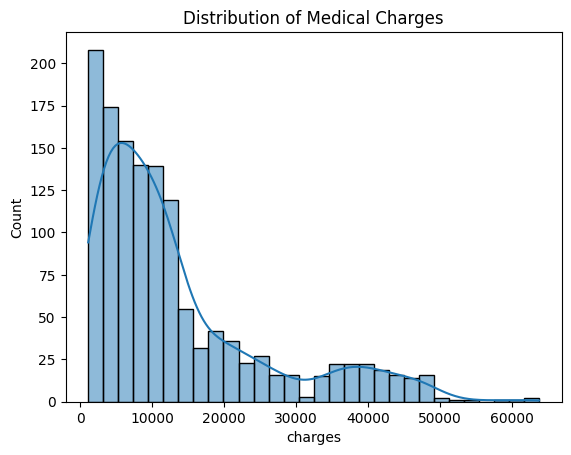

In [5]:
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

In [6]:
df['charges'].min()

np.float64(1121.8739)

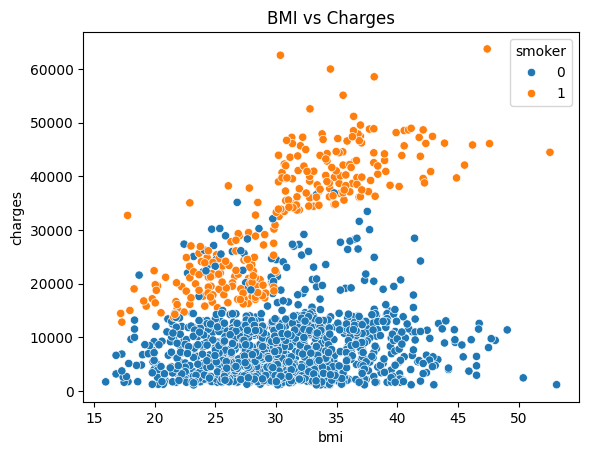

In [7]:
sns.scatterplot(data = df, x = 'bmi', y = 'charges', hue = 'smoker')
plt.title("BMI vs Charges")
plt.show()

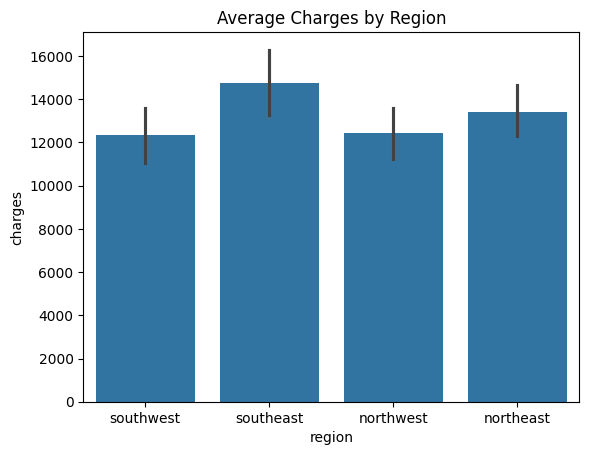

In [8]:
sns.barplot(data=df, x = 'region', y = 'charges')
plt.title("Average Charges by Region")
plt.show()

## Preparing Data for Modeling

Defining Features and Target

In [9]:
X = df.drop('charges', axis=1)
y = df['charges']

Categorical vs Numeric

In [10]:
categorical = ['sex', 'region']
numeric = ['age', 'bmi', 'children', 'smoker']

Preprocessing Pipeline

In [11]:
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

Trainging Prediction Model

In [12]:
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## Evaluating the Model

In [15]:
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

rmse, r2

(np.float64(4598.8065527268545), 0.8637733042570842)

## Extracting Feature Importance

In [16]:
importances = model.named_steps['rf'].feature_importances_
feature_names = model.named_steps['preprocess'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df

,feature,importance
7,num__smoker,0.610025
5,num__bmi,0.214866
4,num__age,0.134195
6,num__children,0.019417
0,cat__sex_male,0.006374
1,cat__region_northwest,0.005688
2,cat__region_southeast,0.005275
3,cat__region_southwest,0.004160


In [17]:
importance_df.to_json("feature_importance.json", orient="records")

## Saving Model for Flask

In [18]:
import os

os.makedirs("../backend/models", exist_ok=True)

In [19]:
joblib.dump(model, "../backend/models/cost_model.pkl")

['../backend/models/cost_model.pkl']

## Building the Lifestyle Risk Scoring Logic

In [20]:
def compute_risk_score(age, bmi, smoker):
    score = 0
    
    if smoker == 1:
        score += 40
    if bmi > 30:
        score += 20
    if age > 50:
        score += 15
    if bmi < 18.5:
        score += 10
    if age < 25:
        score += 5
    
    return score

In [21]:
def risk_level(score):
    if score <= 20:
        return "Low"
    elif score <= 40:
        return "Moderate"
    elif score <= 60:
        return "High"
    else:
        return "Very High"

In [22]:
joblib.dump((compute_risk_score, risk_level), "../backend/models/risk_scoring.pkl")

['../backend/models/risk_scoring.pkl']

## Exporting Cleaned Data for DB Insertion

In [23]:
df.to_csv("cleaned.csv", index=False)
